# Week 5: 1D Advection

### Import libraries

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

### Construct the update matrix depending on the method: FTCS or Lax

In [27]:
def construct_update_matrix(L, what_method, g):
    # Constructs an update matrix
    # inputs:
    # L is the number of spatial steps
    # what_method sets the method of choice: ftcs or lax
    # g = c*tau/h is a constant
    #-------------------------------------------------------------------------------

    # Diagonal matrix to implement the centred spatial first-derivative
    # Common across both methods
    D = np.zeros((L, L))
        
    # Fill diagonals
    for i in range(L-1):
        D[i, i+1] = 1     # Super-diagonal
        D[i+1, i] = -1    # Sub-diagonal 
        
    # Additional elements for periodic boundary conditions
    D[0, L-1] = -1        
    D[L-1, 0] = 1     
  
    if what_method == 'ftcs':
               
        # FTCS Update matrix for advection
        M = np.eye(L) - 0.5*g*D
        
    elif what_method == 'lax':
        
        # Lax averaging matrix
        A = 0.5*np.abs(D)
        
        # Lax Update matrix for advection
        M = A - 0.5*g*D
        
    else:
        
        raise ValueError(f"Unknown method: '{what_method}'")
    
    return M

### Define the function to solve the advection equation

In [28]:
def advection(what_method, tau):
    # Solve the advection equation with periodic BCs using what_method
        
    if what_method == 'ftcs':
        
        print('Using the FTCS method!')
        
    elif what_method == 'lax':
        
        print('Using the Lax method!')
    else:
        raise ValueError(f"Unknown method '{what_method}'")
        
    
    
    # --- Set parameters: --- #
    
    # Propagation speed:
    c = 1
    
    # Spatial step:
    h = 0.01
    
    
    #--------------------------------------------------------------------------
    #  Initialization
    #--------------------------------------------------------------------------

    # Number of steps such that the pulse should propagate through
    # the periodic domain once
    numSteps = int(np.ceil((1+h)/(c*tau)))
    
    # Vector of x values
    x = np.arange(0, 1 + h, h)
    L = len(x)
    
    #-------------------------------------------------------------------------------
    #  Construct the update matrix, M
    #-------------------------------------------------------------------------------
    g = c * tau / h

    M = construct_update_matrix(L, what_method, g)

    # Calculate the spectral radius of M
    eigenvalues = np.linalg.eigvals(M)
    rho = max(abs(eigenvalues))
    
    print(f"Spectral radius: {rho:.4f}")
    
    #-------------------------------------------------------------------------------
    #  Set Initial conditions (a Gaussian pulse at x = 0.5)
    #-------------------------------------------------------------------------------
   
    sig = 0.1
    amp = np.exp(-0.5 * (x - 0.5)**2 / sig**2)
    amp0 = amp.copy()  # store initial profile
    
    # Record a(x,t) matrix for visualisation
    amp_xt = np.zeros((L, numSteps + 1))
    amp_xt[:, 0] = amp0
    
    # Precompute discretisation of time:
    time = np.arange(numSteps + 1) * tau
    
    # Initialise array for analytical solution
    analytic_xt = np.zeros((L, numSteps + 1))
    analytic_xt[:, 0] = amp0  # Initial condition
    
    #-------------------------------------------------------------------------------
    # March forwards in time:
    #-------------------------------------------------------------------------------
    
    for n in range(numSteps):
        
        # Update the wave amplitude profile:
        amp = M @ amp
        
        # Calculate the profile for the exact analytic solution
        k = int(np.floor(c * time[n+1] / h))  # The index the peak has reached
        xp = np.concatenate((x[k:], x[:k]))  # Shift x to left by k steps
        
        analytic_xt[:, n+1] = np.roll(amp0, k)
        
        # Record a(x,t) matrix for visualisation
        amp_xt[:, n+1] = amp
    
    
    return numSteps, xp, analytic_xt, amp0, amp_xt, time

### Solve the advection equation using either FTCS or Lax method

In [32]:
#----------------------solve the equations--------------#
what_method = 'ftcs' # set the method to be used
tau = 0.01 # set time step
numSteps, xp, analytic_xt, amp0, amp_xt, time = advection(what_method, tau)
#----------------------solve the equations--------------#

Using the FTCS method!
Spectral radius: 1.4141


### Output results as an animation

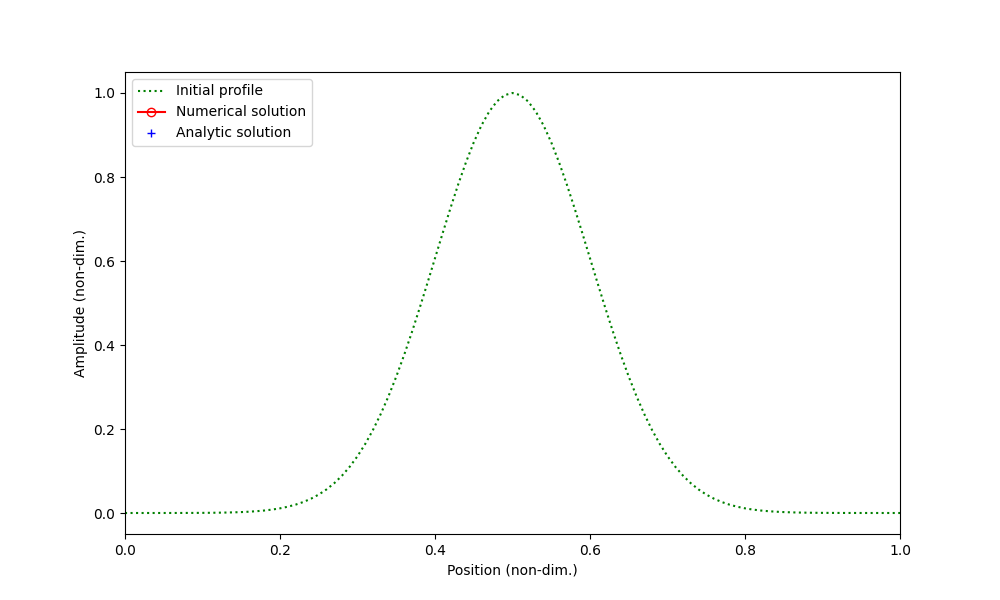

In [33]:

#-------------------------------------------------------------------------------
# Plot the results as an animation
%matplotlib widget
# This enables interactive mode; uncomment and run the following line to go back to static:
# %matplotlib inline

# Set up figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('Position (non-dim.)')
ax.set_ylabel('Amplitude (non-dim.)')
ax.set_xlim(0, 1)

# Plot initial profile
ax.plot(xp, amp0, ':', color='g', linewidth=1.5, label='Initial profile')

# Create empty artists
plot1, = ax.plot([], [], '-o', color='red', markerfacecolor='none',
                 markeredgecolor='red', linewidth=1.5, label='Numerical solution')
plot2, = ax.plot([], [], '+', color='blue', markeredgecolor='blue',
                 label='Analytic solution')
title = ax.text(0.5, 1.02, '', transform=ax.transAxes,
                size=12, horizontalalignment='center')

def update(i):
    # Update data
    plot1.set_data(xp, amp_xt[:, i])
    plot2.set_data(xp, analytic_xt[:, i])

    # Autoscale y-axis for this frame
    ymin = min(np.min(amp_xt[:, i]), np.min(analytic_xt[:, i]))
    ymax = max(np.max(amp_xt[:, i]), np.max(analytic_xt[:, i]))
    pad = 0.05 * (ymax - ymin) if ymax > ymin else 0.05
    ax.set_ylim(ymin - pad, ymax + pad)

    # Update title
    title.set_text(f'Method: {what_method}, Time: {i*time[1]:.2g}')

    return plot1, plot2, title

ani = animation.FuncAnimation(
    fig=fig,
    func=update,
    frames=numSteps + 1,
    interval=50,
    blit=False,
    repeat=False
)

ax.legend(loc='upper left')
plt.show()

### Output results as a 3D plot

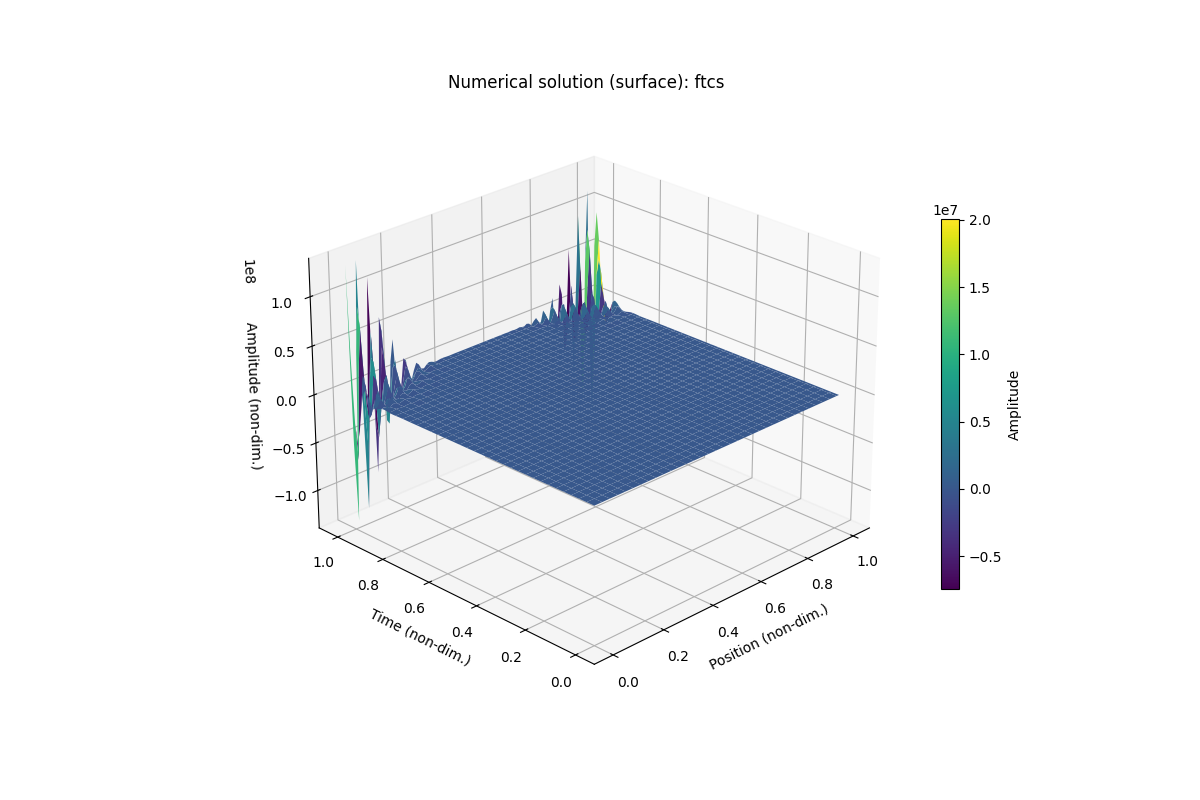

In [34]:
#-------------------------------------------------------------------------------
# Plot the results as a 3D surface
# Create grids
X, T = np.meshgrid(xp, time)
Z_num = amp_xt.T

# Figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface plot (no wireframe)
surf = ax.plot_surface(X, T, Z_num, cmap='viridis', edgecolor='none')

# Labels
ax.set_xlabel('Position (non-dim.)')
ax.set_ylabel('Time (non-dim.)')
ax.set_zlabel('Amplitude (non-dim.)')

# Rotate view (time left, position right)
ax.view_init(elev=25, azim=-135)

# Optional: colorbar for amplitude
fig.colorbar(surf, ax=ax, shrink=0.6, label='Amplitude')

ax.set_title(f'Numerical solution (surface): {what_method}')

plt.show()